# 01 | Dataset exploration and acquisition metadata

## Steel microstructure image dataset

This notebook characterizes the image collection and its associated metadata before model development. The audit covers class composition, specimen identity, microscope and magnification information, image integrity, metadata consistency, and possible duplicate records.

**Research motivation.** Patches obtained from related specimens or acquisition sessions may share visual characteristics unrelated to phase identity. Dataset composition and grouping information must therefore be examined before designing independent evaluation partitions.

**Scope.** Exploratory inspection only; no images or metadata records are modified and no model is trained.

## 1. Data locations

Paths to the microscopy image directory, metadata CSV and analysis output directory.

In [5]:
from pathlib import Path

IMAGE_DIR = Path(r"../data/raw/Dataset")
METADATA_PATH = Path(r"../data/raw/Dataset_Patches_Microscope_Metadata.csv")

# Optional: where generated EDA tables will be saved.
# Leave as None to create an "eda_outputs" folder beside this notebook.
OUTPUT_DIR = Path(r"../results/01_dataset_exploration")


## 2. Environment

Libraries used for metadata analysis, image inspection and visualization.

In [6]:
import sys
import hashlib
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError
from IPython.display import display

warnings.filterwarnings("ignore")

print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)


Python: 3.13.9
Pandas: 3.0.5
NumPy: 2.3.5


## 3. Input validation

Resolve the configured paths and verify that the image directory and metadata file are accessible.

In [8]:
IMAGE_DIR = IMAGE_DIR.expanduser().resolve()
METADATA_PATH = METADATA_PATH.expanduser().resolve()

if OUTPUT_DIR is None:
    OUTPUT_DIR = Path.cwd() / "eda_outputs"
else:
    OUTPUT_DIR = Path(OUTPUT_DIR).expanduser().resolve()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Image directory :", IMAGE_DIR)
print("Metadata file   :", METADATA_PATH)
print("Output directory:", OUTPUT_DIR)
print()

assert IMAGE_DIR.exists() and IMAGE_DIR.is_dir(), (
    f"Dataset folder not found:\n{IMAGE_DIR}\n"
    "Edit IMAGE_DIR in the USER CONFIGURATION cell."
)
assert METADATA_PATH.exists() and METADATA_PATH.is_file(), (
    f"Metadata file not found:\n{METADATA_PATH}\n"
    "Edit METADATA_PATH in the USER CONFIGURATION cell."
)

print("Paths validated successfully.")


Image directory : D:\AI_Materials_Microscopy\data\raw\Dataset
Metadata file   : D:\AI_Materials_Microscopy\data\raw\Dataset_Patches_Microscope_Metadata.csv
Output directory: D:\AI_Materials_Microscopy\results\01_dataset_exploration

Paths validated successfully.


## 4. Metadata import

Load the CSV metadata table and inspect its dimensions.

In [15]:
# Load metadata from CSV
metadata = pd.read_csv(METADATA_PATH)

print("Metadata loaded successfully")
print(f"Rows   : {metadata.shape[0]:,}")
print(f"Columns: {metadata.shape[1]:,}")

display(metadata.head())

Metadata loaded successfully
Rows   : 5,327
Columns: 13


,FileNameHarm,ID,SampleIDHarm,Magnification,ImageSizePx,MicroscopeID,EtchingID,ExposureHarm,ApertureHarm,ObjectivHarm,FilterHarm,Phase,PatchID
0,38_A_Bainite_01,38,A,20x,96,0,0,medium,high,standard,DLF,Bainite,1
1,38_A_Bainite_02,38,A,20x,96,0,0,medium,high,standard,DLF,Bainite,2
2,38_A_Bainite_03,38,A,20x,96,0,0,medium,high,standard,DLF,Bainite,3
3,38_A_Bainite_04,38,A,20x,96,0,0,medium,high,standard,DLF,Bainite,4
4,38_A_Bainite_05,38,A,20x,96,0,0,medium,high,standard,DLF,Bainite,5


## 5. Metadata schema

Review field names, data types, completeness and cardinality to distinguish identifiers, experimental factors and target labels.

In [16]:
schema = pd.DataFrame({
    "column": metadata.columns,
    "dtype": [str(metadata[c].dtype) for c in metadata.columns],
    "non_null": [metadata[c].notna().sum() for c in metadata.columns],
    "missing": [metadata[c].isna().sum() for c in metadata.columns],
    "unique": [metadata[c].nunique(dropna=True) for c in metadata.columns],
})

display(schema)

print("\nColumn names:")
for i, c in enumerate(metadata.columns, 1):
    print(f"{i:2d}. {c}")


,column,dtype,non_null,missing,unique
0,FileNameHarm,str,5327,0,5327
1,ID,int64,5327,0,474
2,SampleIDHarm,str,5327,0,20
3,Magnification,str,5327,0,3
4,ImageSizePx,int64,5327,0,2
5,MicroscopeID,int64,5327,0,3
6,EtchingID,int64,5327,0,2
7,ExposureHarm,str,5327,0,3
8,ApertureHarm,str,5327,0,3
9,ObjectivHarm,str,5327,0,2



Column names:
 1. FileNameHarm
 2. ID
 3. SampleIDHarm
 4. Magnification
 5. ImageSizePx
 6. MicroscopeID
 7. EtchingID
 8. ExposureHarm
 9. ApertureHarm
10. ObjectivHarm
11. FilterHarm
12. Phase
13. PatchID


## 6. Missing metadata

Quantify missing values that could limit image matching, subgroup comparisons or specimen-disjoint partitioning.

In [18]:
missing = pd.DataFrame({
    "missing_count": metadata.isna().sum(),
    "missing_percent": metadata.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing = missing[missing["missing_count"] > 0]

if missing.empty:
    print("No missing values found in the metadata.")
else:
    display(missing.round(2))

No missing values found in the metadata.


## 7. Duplicate metadata records

Identify exact repeated rows. Duplicate records are reported but retained during exploratory analysis.

In [19]:
n_duplicates = metadata.duplicated().sum()
print(f"Exact duplicate metadata rows: {n_duplicates:,}")

if n_duplicates:
    display(metadata[metadata.duplicated(keep=False)].head(20))


Exact duplicate metadata rows: 0


## 8. Image inventory

Enumerate image files recursively across the nested dataset directories.

In [20]:
IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg", ".tif", ".tiff",
    ".bmp", ".gif", ".webp"
}

image_files = sorted([
    p for p in IMAGE_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
])

print(f"Total microscopy image files discovered: {len(image_files):,}")

extension_counts = Counter(p.suffix.lower() for p in image_files)
display(
    pd.DataFrame(
        sorted(extension_counts.items()),
        columns=["extension", "count"]
    )
)

print("\nFirst 20 relative paths:")
for p in image_files[:20]:
    print(" •", p.relative_to(IMAGE_DIR))


Total microscopy image files discovered: 5,328


,extension,count
0,.png,5328



First 20 relative paths:
 • A_Bainite_1\38_A_Bainite_01.png
 • A_Bainite_1\39_A_Bainite_01.png
 • A_Bainite_1\40_A_Bainite_01.png
 • A_Bainite_1\41_A_Bainite_01.png
 • A_Bainite_1\42_A_Bainite_01.png
 • A_Bainite_1\43_A_Bainite_01.png
 • A_Bainite_1\44_A_Bainite_01.png
 • A_Bainite_1\45_A_Bainite_01.png
 • A_Bainite_1\46_A_Bainite_01.png
 • A_Bainite_1\47_A_Bainite_01.png
 • A_Bainite_1\48_A_Bainite_01.png
 • A_Bainite_1\49_A_Bainite_01.png
 • A_Bainite_1\50_A_Bainite_01.png
 • A_Bainite_1\51_A_Bainite_01.png
 • A_Bainite_1\52_A_Bainite_01.png
 • A_Bainite_1\53_A_Bainite_01.png
 • A_Bainite_1\54_A_Bainite_01.png
 • A_Bainite_1\55_A_Bainite_01.png
 • A_Bainite_1\56_A_Bainite_01.png
 • A_Bainite_1\57_A_Bainite_01.png


## 9. Directory composition

Summarize image counts within each top-level directory to inspect how the collection is organized.

In [21]:
top_level_summary = []

for item in sorted(IMAGE_DIR.iterdir()):
    if item.is_dir():
        n_imgs = sum(
            1 for p in item.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )
        top_level_summary.append((item.name, n_imgs))

if top_level_summary:
    folder_df = pd.DataFrame(
        top_level_summary,
        columns=["top_level_folder", "image_count"]
    ).sort_values("image_count", ascending=False)
    display(folder_df)
else:
    print("No subdirectories found directly under IMAGE_DIR.")


,top_level_folder,image_count
31,D_Bainite_11,57
36,D_Bainite_5,57
29,D_Bainite_1,57
30,D_Bainite_10,57
32,D_Bainite_12,57
...,...,...
213,S_Bainite_6,18
212,S_Bainite_5,18
207,S_Bainite_11,18
210,S_Bainite_3,18


## 10. Image integrity and technical characteristics

Check file readability, spatial dimensions and image modes. These properties influence preprocessing choices and can reveal inconsistencies between acquisitions.

In [22]:
image_records = []
bad_images = []

for p in image_files:
    try:
        with Image.open(p) as img:
            width, height = img.size
            image_records.append({
                "path": str(p),
                "relative_path": str(p.relative_to(IMAGE_DIR)),
                "filename": p.name,
                "stem": p.stem,
                "extension": p.suffix.lower(),
                "width": width,
                "height": height,
                "mode": img.mode,
            })
    except (UnidentifiedImageError, OSError, ValueError) as e:
        bad_images.append((str(p), str(e)))

images_df = pd.DataFrame(image_records)

print(f"Readable images: {len(images_df):,}")
print(f"Unreadable/corrupt images: {len(bad_images):,}")

if bad_images:
    display(pd.DataFrame(bad_images, columns=["path", "error"]).head(20))

display(images_df.head())


Readable images: 5,328
Unreadable/corrupt images: 0


,path,relative_path,filename,stem,extension,width,height,mode
0,D:\AI_Materials_Microscopy\data\raw\Dataset\A_...,A_Bainite_1\38_A_Bainite_01.png,38_A_Bainite_01.png,38_A_Bainite_01,.png,96,96,RGB
1,D:\AI_Materials_Microscopy\data\raw\Dataset\A_...,A_Bainite_1\39_A_Bainite_01.png,39_A_Bainite_01.png,39_A_Bainite_01,.png,96,96,RGB
2,D:\AI_Materials_Microscopy\data\raw\Dataset\A_...,A_Bainite_1\40_A_Bainite_01.png,40_A_Bainite_01.png,40_A_Bainite_01,.png,96,96,RGB
3,D:\AI_Materials_Microscopy\data\raw\Dataset\A_...,A_Bainite_1\41_A_Bainite_01.png,41_A_Bainite_01.png,41_A_Bainite_01,.png,96,96,RGB
4,D:\AI_Materials_Microscopy\data\raw\Dataset\A_...,A_Bainite_1\42_A_Bainite_01.png,42_A_Bainite_01.png,42_A_Bainite_01,.png,96,96,RGB


### Image dimensions and channels

Summarize the observed image modes and dimensions.

In [23]:
if not images_df.empty:
    print("Image modes:")
    display(images_df["mode"].value_counts().rename_axis("mode").to_frame("count"))

    print("\nMost common image dimensions:")
    dimensions = (
        images_df.groupby(["width", "height"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    display(dimensions.head(20))

    print("\nWidth / height statistics:")
    display(images_df[["width", "height"]].describe().round(2))


Image modes:


,count
mode,
RGB,5328



Most common image dimensions:


,width,height,count
1,256,256,2799
0,96,96,2529



Width / height statistics:


,width,height
count,5328.00,5328.00
mean,180.05,180.05
std,79.90,79.90
min,96.00,96.00
25%,96.00,96.00
50%,256.00,256.00
75%,256.00,256.00
max,256.00,256.00


## 11. Repeated filenames

Check whether the same filename appears in multiple directories. Filename collisions can complicate metadata joins even when the underlying images differ.

In [24]:
if not images_df.empty:
    duplicate_names = images_df[
        images_df["filename"].duplicated(keep=False)
    ].sort_values("filename")

    print(
        "Images whose filename occurs more than once:",
        f"{len(duplicate_names):,}"
    )

    if not duplicate_names.empty:
        display(
            duplicate_names[
                ["filename", "relative_path", "width", "height"]
            ].head(30)
        )


Images whose filename occurs more than once: 0


## 12. Categorical metadata

Inspect low-cardinality fields for class and acquisition distributions, including potential imbalance.

In [25]:
MAX_CATEGORIES_TO_DISPLAY = 30

categorical_candidates = []

for col in metadata.columns:
    n_unique = metadata[col].nunique(dropna=True)
    if 1 < n_unique <= MAX_CATEGORIES_TO_DISPLAY:
        categorical_candidates.append(col)

print("Low-cardinality candidate columns:")
for col in categorical_candidates:
    print(f"\n--- {col} ---")
    counts = metadata[col].value_counts(dropna=False)
    display(counts.to_frame("count"))


Low-cardinality candidate columns:

--- SampleIDHarm ---


,count
SampleIDHarm,
D,684
C,456
A,342
B,304
L,266
E,228
F,228
G,228
I,228



--- Magnification ---


,count
Magnification,
50x,2551
20x,2529
100x,247



--- ImageSizePx ---


...

,count
FilterHarm,
noFilter,4203
DLF,1124



--- Phase ---


,count
Phase,
Martensite,2850
Bainite,2477



--- PatchID ---


,count
PatchID,
1,626
2,626
3,588
4,512
5,493
6,436
7,379
8,379
9,360


## 13. Candidate experimental variables

Use column-name heuristics to identify possible phase, specimen, microscope, magnification and image identifiers. These suggestions require confirmation against the metadata definitions.

In [26]:
def find_columns(keywords):
    matches = []
    for col in metadata.columns:
        name = str(col).lower().replace("_", " ").replace("-", " ")
        if any(k.lower() in name for k in keywords):
            matches.append(col)
    return matches

candidate_groups = {
    "class / label / phase": find_columns(
        ["class", "label", "phase", "microstructure", "structure", "type"]
    ),
    "microscope / instrument": find_columns(
        ["microscope", "instrument", "device", "camera"]
    ),
    "magnification": find_columns(
        ["magnification", "magnif", "zoom"]
    ),
    "sample / specimen": find_columns(
        ["sample", "specimen", "material", "steel"]
    ),
    "image / file / patch": find_columns(
        ["image", "file", "filename", "patch", "path"]
    ),
}

for group, cols in candidate_groups.items():
    print(f"{group:24s}: {cols if cols else 'No obvious match'}")


class / label / phase   : ['Phase']
microscope / instrument : ['MicroscopeID']
magnification           : ['Magnification']
sample / specimen       : ['SampleIDHarm']
image / file / patch    : ['FileNameHarm', 'ImageSizePx', 'PatchID']


## 14. Metadata distributions

Visualize selected categorical variables to examine class frequencies and acquisition-domain representation.

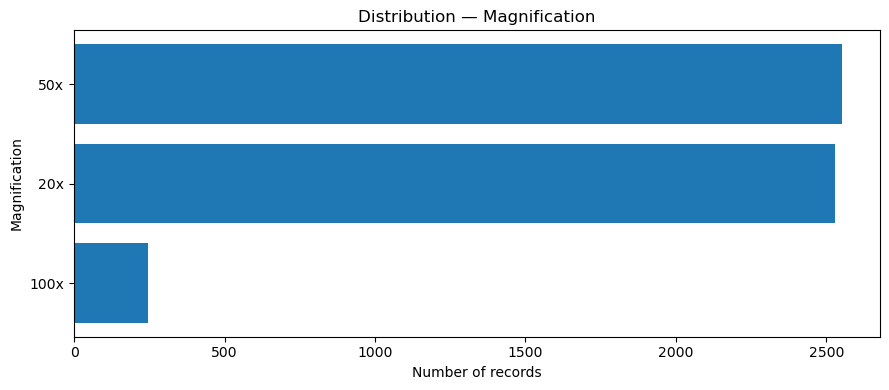

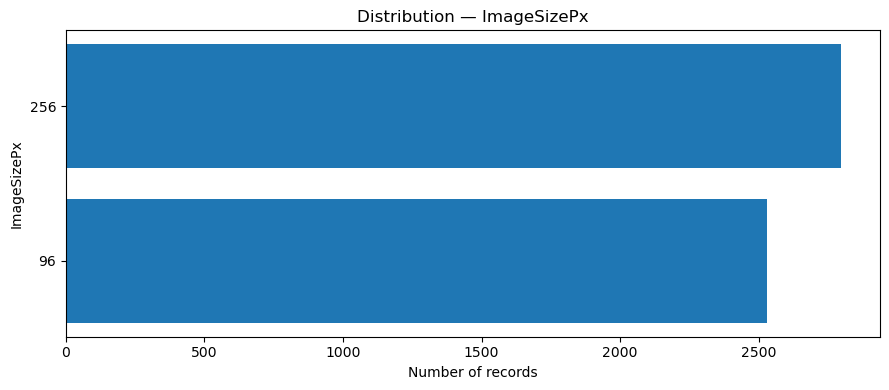

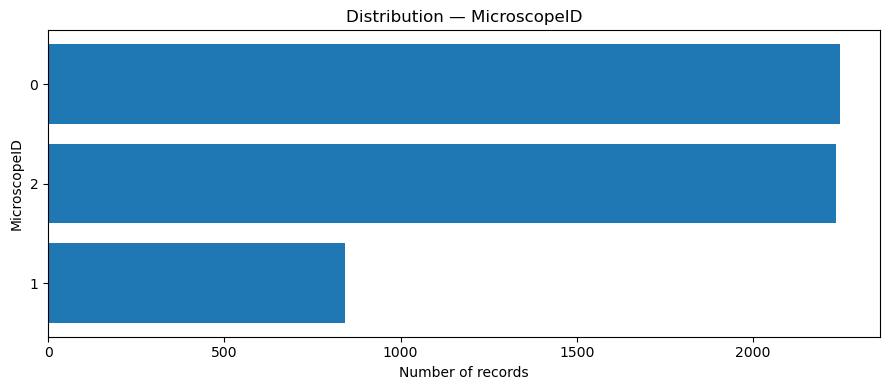

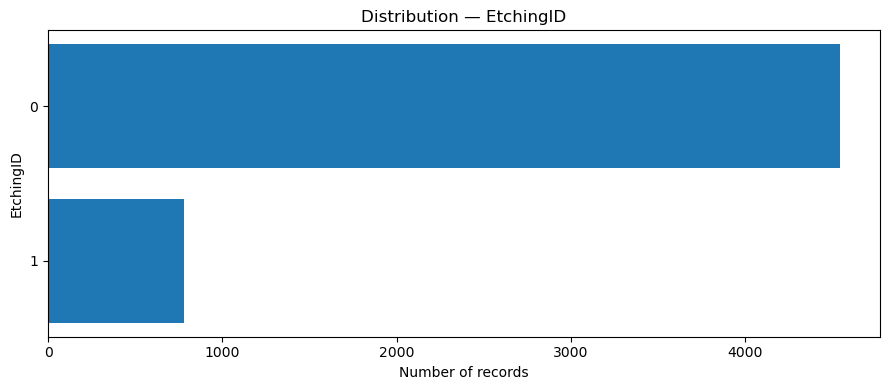

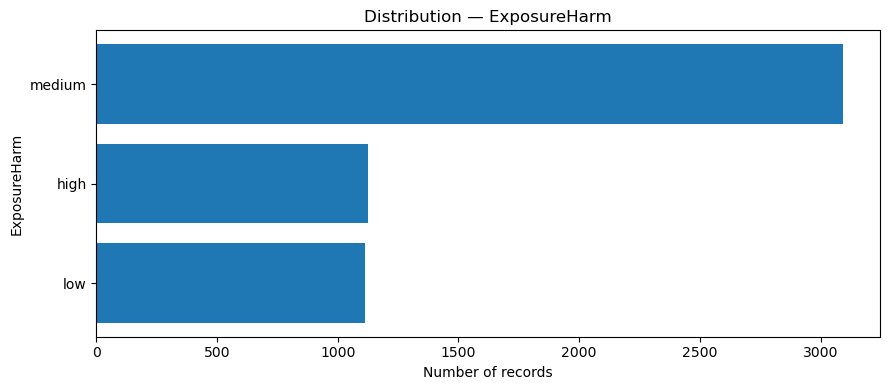

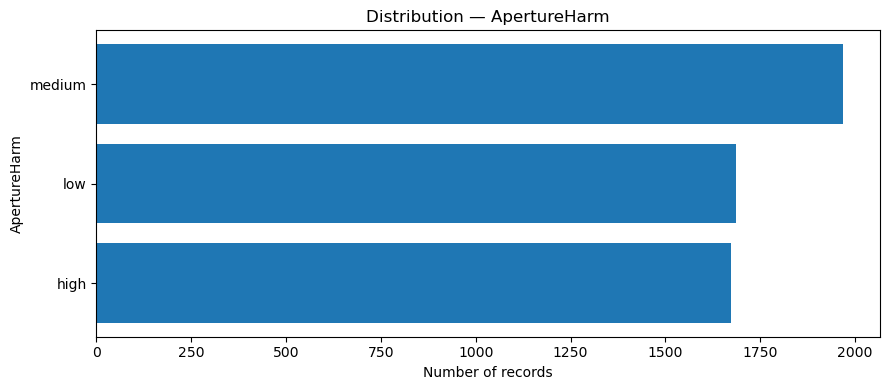

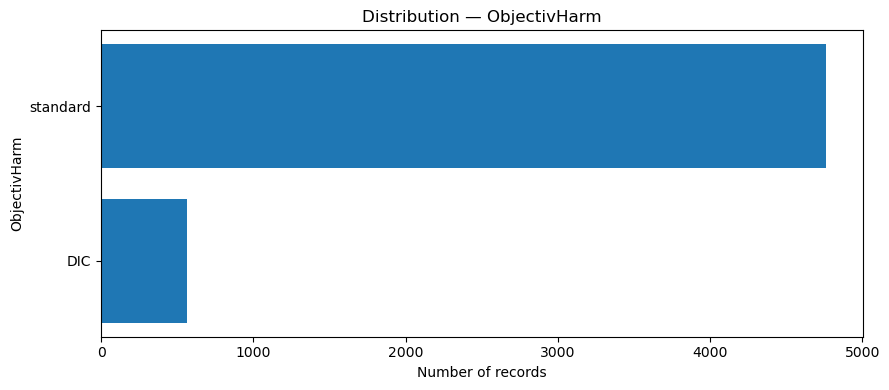

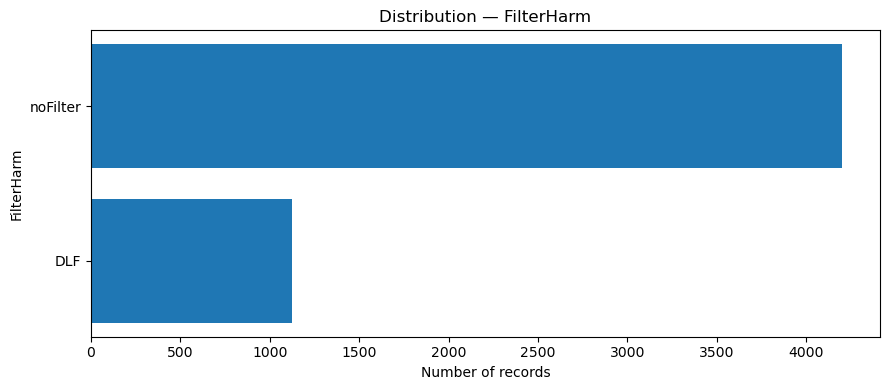

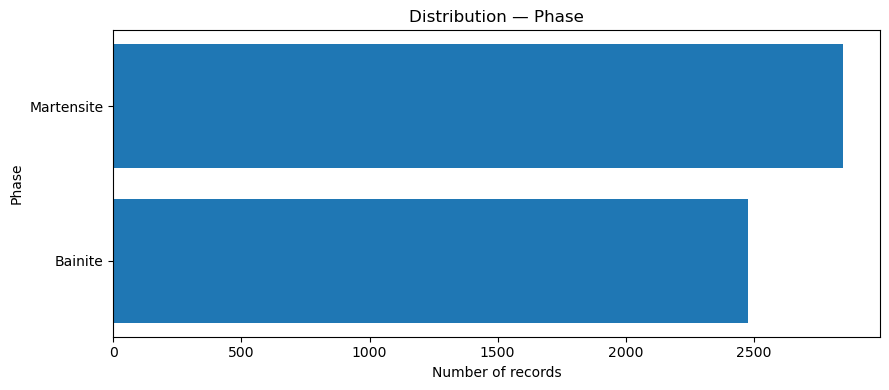

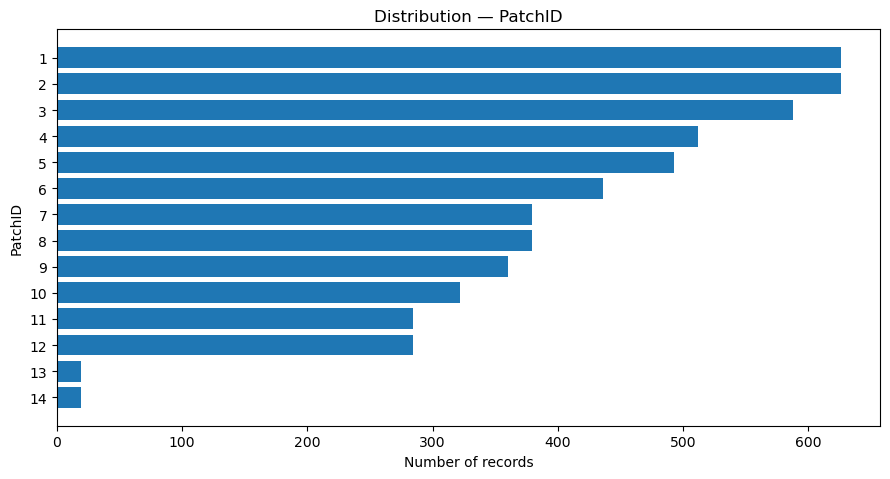

In [27]:
plot_candidates = [
    c for c in categorical_candidates
    if metadata[c].nunique(dropna=True) <= 15
]

for col in plot_candidates:
    counts = metadata[col].astype(str).value_counts().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(counts))))
    ax.barh(counts.index[::-1], counts.values[::-1])
    ax.set_title(f"Distribution — {col}")
    ax.set_xlabel("Number of records")
    ax.set_ylabel(col)
    fig.tight_layout()
    plt.show()


## 15. Numerical metadata

Summarize numerical columns and their ranges, where present.

In [28]:
numeric_cols = metadata.select_dtypes(include=np.number).columns.tolist()

if numeric_cols:
    display(metadata[numeric_cols].describe().T.round(3))
else:
    print("No numerical metadata columns detected.")


,count,mean,std,min,25%,50%,75%,max
ID,5327.0,449.717,252.622,38.0,247.0,437.0,642.5,892.0
ImageSizePx,5327.0,180.040,79.905,96.0,96.0,256.0,256.0,256.0
MicroscopeID,5327.0,0.998,0.918,0.0,0.0,1.0,2.0,2.0
EtchingID,5327.0,0.146,0.353,0.0,0.0,0.0,0.0,1.0
PatchID,5327.0,5.624,3.426,1.0,3.0,5.0,8.0,14.0


## 16. Metadata–image correspondence

Assess possible filename-, stem- and identifier-based matches between the metadata and discovered images. Matching remains diagnostic at this stage; unresolved records require examination before modelling.

In [29]:
if images_df.empty:
    print("No readable images available for matching.")
else:
    filenames = set(images_df["filename"].astype(str))
    stems = set(images_df["stem"].astype(str))
    relpaths = set(images_df["relative_path"].astype(str))

    match_results = []

    for col in metadata.columns:
        vals = metadata[col].dropna().astype(str).str.strip()

        if len(vals) == 0:
            continue

        exact_filename = vals.isin(filenames).mean()
        exact_stem = vals.isin(stems).mean()
        exact_relpath = vals.str.replace("\\", "/", regex=False).isin(
            {p.replace("\\", "/") for p in relpaths}
        ).mean()

        best = max(exact_filename, exact_stem, exact_relpath)

        if best > 0:
            match_results.append({
                "metadata_column": col,
                "filename_match_%": 100 * exact_filename,
                "stem_match_%": 100 * exact_stem,
                "relative_path_match_%": 100 * exact_relpath,
                "best_match_%": 100 * best,
            })

    if match_results:
        matching_df = (
            pd.DataFrame(match_results)
            .sort_values("best_match_%", ascending=False)
        )
        display(matching_df.round(2))
    else:
        print(
            "No direct filename/stem/path match was detected.\n"
            "This is not necessarily a problem: the metadata may use IDs "
            "encoded within filenames rather than exact filenames."
        )


,metadata_column,filename_match_%,stem_match_%,relative_path_match_%,best_match_%
0,FileNameHarm,0.0,99.98,0.0,99.98


## 17. Representative micrographs

Display a reproducible image sample to inspect texture, contrast, scale and possible acquisition artifacts. Visual inspection is qualitative and does not establish phase-label correctness.

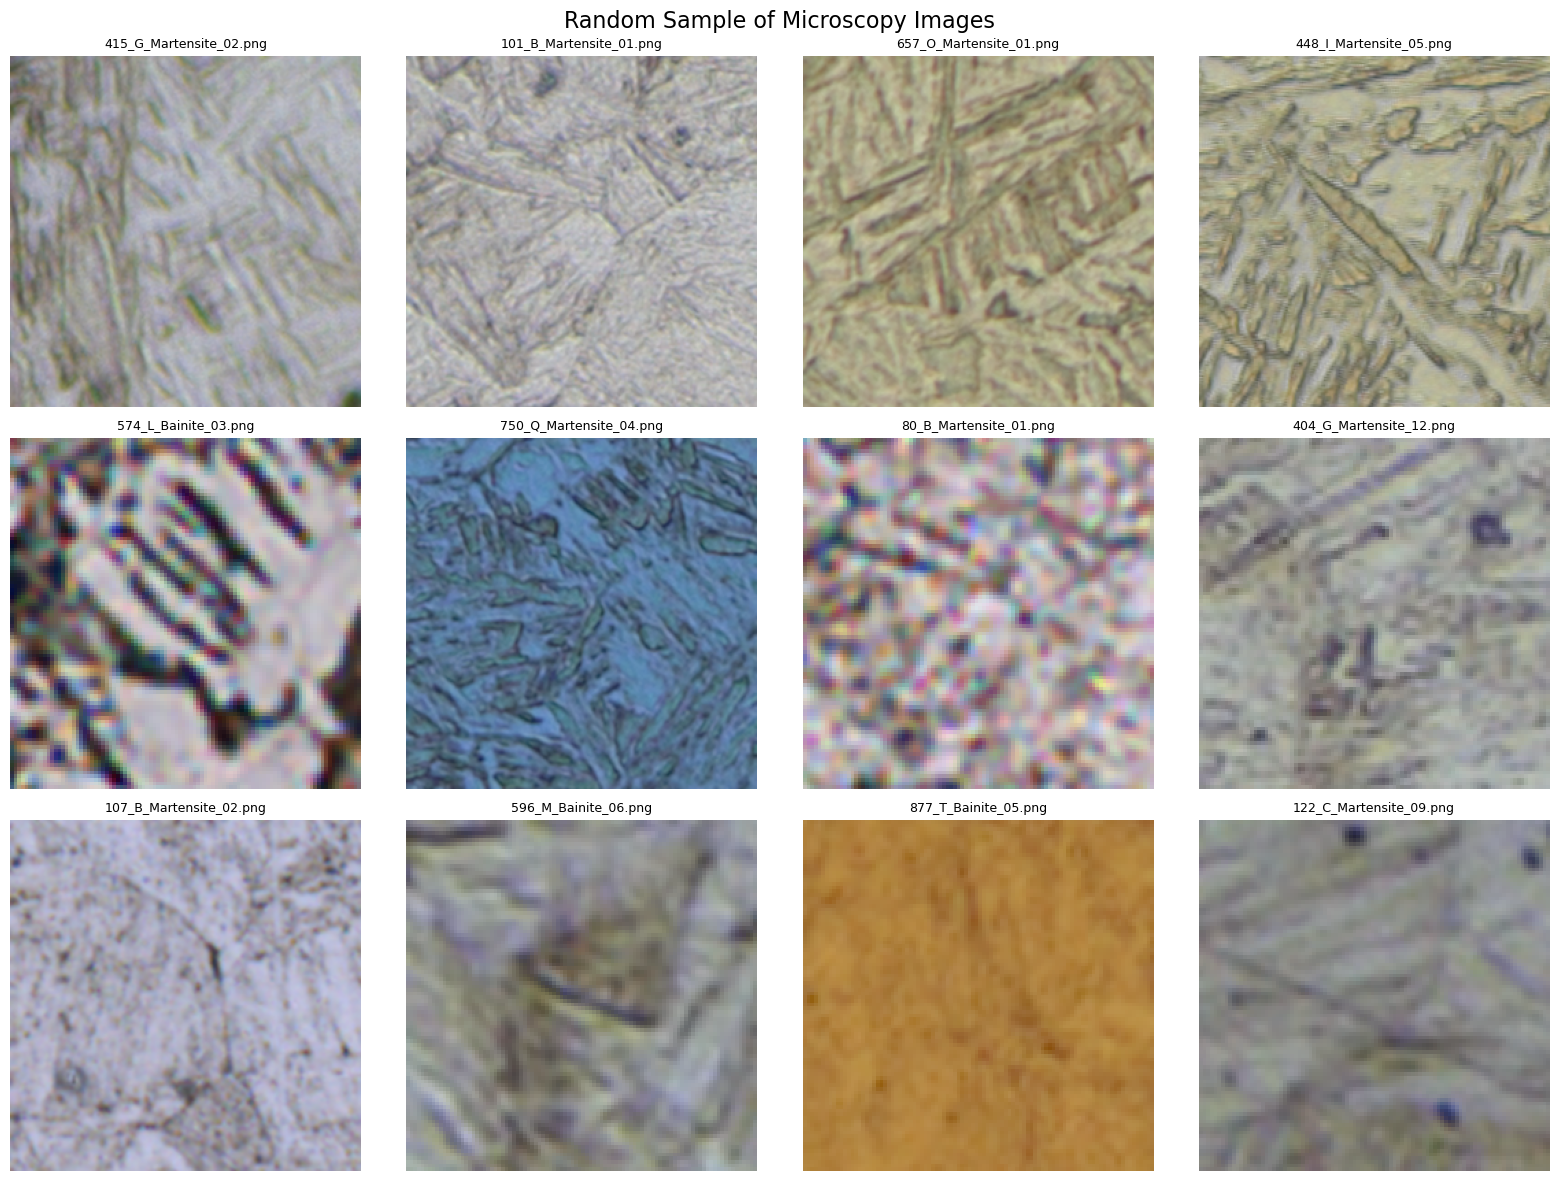

In [30]:
N_EXAMPLES = 12
RANDOM_SEED = 42

if len(image_files) == 0:
    print("No images available.")
else:
    rng = np.random.default_rng(RANDOM_SEED)
    chosen_idx = rng.choice(
        len(image_files),
        size=min(N_EXAMPLES, len(image_files)),
        replace=False
    )
    chosen = [image_files[i] for i in chosen_idx]

    ncols = 4
    nrows = int(np.ceil(len(chosen) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, p in zip(axes, chosen):
        with Image.open(p) as img:
            ax.imshow(img, cmap="gray" if img.mode in ("L", "I", "F") else None)
        ax.set_title(p.name, fontsize=9)
        ax.axis("off")

    for ax in axes[len(chosen):]:
        ax.axis("off")

    fig.suptitle("Random Sample of Microscopy Images", fontsize=16)
    fig.tight_layout()
    plt.show()


## 18. Pixel-intensity variation

Measure basic brightness and contrast statistics for an image subset. Differences may reflect microstructure, preparation or acquisition settings and therefore warrant cautious interpretation.

,mean_intensity,std_intensity,min_intensity,max_intensity
count,500.00,500.00,500.00,500.00
mean,134.11,19.90,56.07,181.54
std,28.71,7.80,24.87,32.16
min,55.84,2.79,0.00,101.00
25%,110.19,14.16,37.00,153.00
50%,134.69,19.15,51.00,182.50
75%,156.60,24.72,73.25,207.00
max,205.86,48.38,149.00,253.00


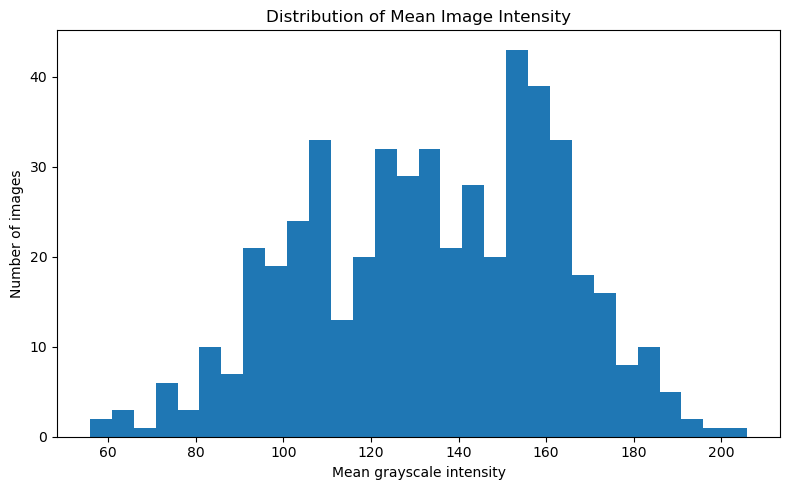

In [31]:
PIXEL_SAMPLE_SIZE = min(500, len(image_files))
pixel_stats = []

if PIXEL_SAMPLE_SIZE > 0:
    rng = np.random.default_rng(42)
    sampled_idx = rng.choice(
        len(image_files),
        size=PIXEL_SAMPLE_SIZE,
        replace=False
    )

    for idx in sampled_idx:
        p = image_files[idx]
        try:
            with Image.open(p) as img:
                arr = np.asarray(img.convert("L"), dtype=np.float32)
                pixel_stats.append({
                    "filename": p.name,
                    "mean_intensity": arr.mean(),
                    "std_intensity": arr.std(),
                    "min_intensity": arr.min(),
                    "max_intensity": arr.max(),
                })
        except Exception:
            pass

    pixel_df = pd.DataFrame(pixel_stats)

    display(pixel_df.describe().round(2))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(pixel_df["mean_intensity"], bins=30)
    ax.set_title("Distribution of Mean Image Intensity")
    ax.set_xlabel("Mean grayscale intensity")
    ax.set_ylabel("Number of images")
    fig.tight_layout()
    plt.show()


## 19. Exact image-duplicate screening

Group byte-identical files using content hashes. Identical images occurring across later evaluation partitions would constitute direct data leakage; visually similar but nonidentical patches are not detected by this check.

In [32]:
def md5_file(path, chunk_size=1024 * 1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

hash_records = []

for p in image_files:
    try:
        hash_records.append({
            "path": str(p),
            "relative_path": str(p.relative_to(IMAGE_DIR)),
            "md5": md5_file(p)
        })
    except OSError:
        pass

hash_df = pd.DataFrame(hash_records)

if not hash_df.empty:
    duplicated_hashes = hash_df[
        hash_df["md5"].duplicated(keep=False)
    ].sort_values("md5")

    n_duplicate_groups = (
        duplicated_hashes["md5"].nunique()
        if not duplicated_hashes.empty else 0
    )

    print(f"Byte-identical duplicate groups: {n_duplicate_groups:,}")
    print(f"Files involved: {len(duplicated_hashes):,}")

    if not duplicated_hashes.empty:
        display(duplicated_hashes.head(30))


Byte-identical duplicate groups: 34
Files involved: 68


,path,relative_path,md5
338,D:\AI_Materials_Microscopy\data\raw\Dataset\A_...,A_Martensite_3\72_A_Martensite_03.png,0d2684af56c86660a1c70142b9437388
339,D:\AI_Materials_Microscopy\data\raw\Dataset\A_...,A_Martensite_3\73_A_Martensite_03.png,0d2684af56c86660a1c70142b9437388
1905,D:\AI_Materials_Microscopy\data\raw\Dataset\E_...,E_Martensite_4\328_E_Martensite_04.png,0db71fb5af715780f7577425fd58951d
1908,D:\AI_Materials_Microscopy\data\raw\Dataset\E_...,E_Martensite_4\331_E_Martensite_04.png,0db71fb5af715780f7577425fd58951d
148,D:\AI_Materials_Microscopy\data\raw\Dataset\A_...,A_Bainite_4\72_A_Bainite_04.png,1003e2cf00b411e2ce0902b3f9d35cfb
149,D:\AI_Materials_Microscopy\data\raw\Dataset\A_...,A_Bainite_4\73_A_Bainite_04.png,1003e2cf00b411e2ce0902b3f9d35cfb
1867,D:\AI_Materials_Microscopy\data\raw\Dataset\E_...,E_Martensite_2\328_E_Martensite_02.png,152235f7c421bfebe98c660353c4a758
1870,D:\AI_Materials_Microscopy\data\raw\Dataset\E_...,E_Martensite_2\331_E_Martensite_02.png,152235f7c421bfebe98c660353c4a758
982,D:\AI_Materials_Microscopy\data\raw\Dataset\C_...,C_Martensite_6\146_C_Martensite_06.png,2c262c49147c11cd9adef04675dc94bd
983,D:\AI_Materials_Microscopy\data\raw\Dataset\C_...,C_Martensite_6\147_C_Martensite_06.png,2c262c49147c11cd9adef04675dc94bd


## 20. Evaluation-grouping considerations

Four distinct evaluation questions are relevant to this dataset:

- **Image-level split:** discrimination among images drawn from the existing collection.
- **Specimen-disjoint split:** transfer to physical specimens absent from model training.
- **Microscope holdout:** sensitivity to changes in acquisition instrument.
- **Magnification holdout:** sensitivity to changes in image scale and field of view.

The analysis below identifies relevant metadata fields; it does not create evaluation partitions.

In [33]:
print("Candidate grouping variables detected from column names:\n")

for group in [
    "class / label / phase",
    "sample / specimen",
    "microscope / instrument",
    "magnification",
    "image / file / patch",
]:
    cols = candidate_groups[group]
    print(f"{group.upper()}")
    if cols:
        for col in cols:
            print(
                f"  • {col}: "
                f"{metadata[col].nunique(dropna=True):,} unique values"
            )
    else:
        print("  • No obvious column detected")
    print()


Candidate grouping variables detected from column names:

CLASS / LABEL / PHASE
  • Phase: 2 unique values

SAMPLE / SPECIMEN
  • SampleIDHarm: 20 unique values

MICROSCOPE / INSTRUMENT
  • MicroscopeID: 3 unique values

MAGNIFICATION
  • Magnification: 3 unique values

IMAGE / FILE / PATCH
  • FileNameHarm: 5,327 unique values
  • ImageSizePx: 2 unique values
  • PatchID: 14 unique values



## 21. Export exploratory tables

Save structured dataset-audit outputs for traceability and subsequent preprocessing.

In [34]:
schema.to_csv(OUTPUT_DIR / "metadata_schema.csv", index=False)

if not images_df.empty:
    images_df.to_csv(OUTPUT_DIR / "image_inventory.csv", index=False)

if 'dimensions' in globals():
    dimensions.to_csv(OUTPUT_DIR / "image_dimensions.csv", index=False)

if 'pixel_df' in globals() and not pixel_df.empty:
    pixel_df.to_csv(OUTPUT_DIR / "pixel_statistics_sample.csv", index=False)

print("Saved EDA outputs to:")
print(OUTPUT_DIR)


Saved EDA outputs to:
D:\AI_Materials_Microscopy\results\01_dataset_exploration


## 22. Dataset-audit summary

Consolidate metadata and image counts, readability, dimensions, duplicate indicators and candidate grouping variables. These are descriptive diagnostics rather than classification results.

In [35]:
print("=" * 72)
print("DATASET EXPLORATION SUMMARY")
print("=" * 72)

print(f"\nMetadata records : {len(metadata):,}")
print(f"Metadata columns : {metadata.shape[1]:,}")
print(f"Images discovered: {len(image_files):,}")
print(f"Readable images  : {len(images_df):,}")
print(f"Corrupt/unreadable images: {len(bad_images):,}")

if not images_df.empty:
    print(
        f"Image width range : "
        f"{images_df['width'].min()}–{images_df['width'].max()} px"
    )
    print(
        f"Image height range: "
        f"{images_df['height'].min()}–{images_df['height'].max()} px"
    )
    print(
        "Image modes       : "
        + ", ".join(
            f"{k} ({v})"
            for k, v in images_df["mode"].value_counts().items()
        )
    )

print(f"\nExact duplicate metadata rows: {metadata.duplicated().sum():,}")

if 'duplicated_hashes' in globals():
    print(
        "Byte-identical image groups: "
        f"{duplicated_hashes['md5'].nunique() if not duplicated_hashes.empty else 0:,}"
    )

print("\nLIKELY EXPERIMENTAL VARIABLES")
for group, cols in candidate_groups.items():
    print(f" • {group}: {cols if cols else 'not automatically identified'}")

print("\nNEXT STEP")
print(
    "Review the metadata columns and distributions above. "
    "The next notebook should construct leakage-resistant "
    "train/validation/test splits using the dataset's actual "
    "class, specimen, microscope, and magnification variables."
)

print("=" * 72)


DATASET EXPLORATION SUMMARY

Metadata records : 5,327
Metadata columns : 13
Images discovered: 5,328
Readable images  : 5,328
Corrupt/unreadable images: 0
Image width range : 96–256 px
Image height range: 96–256 px
Image modes       : RGB (5328)

Exact duplicate metadata rows: 0
Byte-identical image groups: 34

LIKELY EXPERIMENTAL VARIABLES
 • class / label / phase: ['Phase']
 • microscope / instrument: ['MicroscopeID']
 • magnification: ['Magnification']
 • sample / specimen: ['SampleIDHarm']
 • image / file / patch: ['FileNameHarm', 'ImageSizePx', 'PatchID']

NEXT STEP
Review the metadata columns and distributions above. The next notebook should construct leakage-resistant train/validation/test splits using the dataset's actual class, specimen, microscope, and magnification variables.


## Interpretation and methodological implications

The exploratory audit establishes the available phase labels, physical-specimen identifiers, acquisition factors and image properties. It also flags possible metadata mismatches and identical-image records that require resolution before training.

The principal methodological concern is dependence between images originating from the same physical specimen. Consequently, conventional image-level evaluation should be complemented by specimen-disjoint testing, with microscope and magnification holdouts used to characterize acquisition sensitivity.

**Boundary of this notebook:** image matching, deduplication and final train/validation/test assignments are performed separately in dataset preparation; the descriptive statistics here should not be treated as the final modelling cohort.

In [36]:
for col in ["Phase", "MicroscopeID", "Magnification", "SampleIDHarm"]:
    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    print("Unique values:", metadata[col].nunique())
    print(metadata[col].value_counts(dropna=False))


Phase
Unique values: 2
Phase
Martensite    2850
Bainite       2477
Name: count, dtype: int64

MicroscopeID
Unique values: 3
MicroscopeID
0    2248
2    2236
1     843
Name: count, dtype: int64

Magnification
Unique values: 3
Magnification
50x     2551
20x     2529
100x     247
Name: count, dtype: int64

SampleIDHarm
Unique values: 20
SampleIDHarm
D    684
C    456
A    342
B    304
L    266
E    228
F    228
G    228
I    228
J    228
K    228
O    228
Q    228
R    228
S    216
M    209
N    209
T    209
H    190
P    190
Name: count, dtype: int64
